<a href="https://colab.research.google.com/github/Dhatrisree123/FeatureSelection/blob/main/Input_Feature_Selection_App_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Input Feature Selection App

**Task:** Given a CSV dataset and a target variable, identify the features that are most useful for building a machine-learning model.

**Input:** CSV file + target variable  
**Output:** Ranked important features + model-based importance + Gemini explanation  
**Usage:** During machine-learning model building


## 1. Install and import required libraries

This notebook uses the current `google.genai` SDK and scikit-learn for an actual model-based feature-importance calculation.

In [3]:
!pip -q install -U google-genai scikit-learn pandas matplotlib

import os
import pandas as pd
import matplotlib.pyplot as plt

from google import genai
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder


## 2. Configure Gemini

Upload your Gemini API key file to Colab and make sure the filename below matches it.

In [6]:
API_KEY_FILE = "/content/gemini_key.txt"

if not os.path.exists(API_KEY_FILE):
    raise FileNotFoundError(
        f"API key file not found: {API_KEY_FILE}. "
        "Upload Gemini_Api_Key.txt to Colab first."
    )

with open(API_KEY_FILE, "r") as f:
    API_Key = f.read().strip()

client = genai.Client(api_key=API_Key)
print("Gemini client configured successfully.")


Gemini client configured successfully.


## 3. Load the CSV dataset

Change only `file_path` when you want to use another CSV file.

In [8]:
file_path = "/content/banana_quality_dataset.csv"

df = pd.read_csv(file_path)

if df.empty:
    raise ValueError("The CSV file is empty.")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Dataset loaded successfully
Rows: 1000
Columns: 16


,sample_id,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,harvest_date,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,1,Manzano,Colombia,1.88,Processing,2.11,Turning,16.83,3.53,21.44,146.92,2023-10-16,13.7,58.2,2440.5,183.6
1,2,Plantain,Guatemala,2.42,Processing,4.25,Ripe,16.73,4.09,26.11,160.48,2023-10-14,5.1,280.2,2374.6,109.8
2,3,Burro,Ecuador,3.57,Premium,6.24,Overripe,21.34,1.63,25.20,225.27,2023-09-08,17.7,1246.9,1191.5,147.7
3,4,Manzano,Ecuador,2.21,Processing,5.39,Ripe,16.75,3.31,13.08,137.80,2023-10-07,13.0,1150.2,2845.1,92.8
4,5,Red Dacca,Ecuador,2.35,Processing,5.84,Ripe,16.90,3.07,12.98,227.84,2023-10-02,4.8,526.0,2136.9,129.7


## 4. Select the target variable

The target is the value we want the ML model to predict.

For the Banana Quality dataset, we use `quality_category`.

In [9]:
target_variable = "quality_category"

if target_variable not in df.columns:
    raise ValueError(
        f"Target '{target_variable}' was not found. Available columns: {df.columns.tolist()}"
    )

X = df.drop(columns=[target_variable])
y = df[target_variable]

print("Target variable:", target_variable)
print("Target classes:", y.unique().tolist())
print("Number of classes:", y.nunique())


Target variable: quality_category
Target classes: ['Processing', 'Premium', 'Good', 'Unripe']
Number of classes: 4


## 5. Basic data checks

We check missing values and identify numeric and categorical columns.

In [10]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Missing values:


,Missing Values
sample_id,0
variety,0
region,0
quality_score,0
quality_category,0
ripeness_index,0
ripeness_category,0
sugar_content_brix,0
firmness_kgf,0
length_cm,0


Numeric features:
['sample_id', 'quality_score', 'ripeness_index', 'sugar_content_brix', 'firmness_kgf', 'length_cm', 'weight_g', 'tree_age_years', 'altitude_m', 'rainfall_mm', 'soil_nitrogen_ppm']

Categorical features:
['variety', 'region', 'ripeness_category', 'harvest_date']


/tmp/ipykernel_960/105276738.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


## 6. Remove obvious identifier columns

Identifier columns such as `sample_id` normally identify a row rather than describe the observation. They can make feature importance misleading, so we exclude obvious ID columns.

Date columns are also excluded from the baseline model because raw dates should be engineered into useful date features first.

In [11]:
id_columns = [c for c in X.columns if "id" in c.lower()]
date_columns = [c for c in X.columns if "date" in c.lower()]

columns_to_drop = sorted(set(id_columns + date_columns))

if columns_to_drop:
    X = X.drop(columns=columns_to_drop)

print("Excluded columns:", columns_to_drop if columns_to_drop else "None")

print("Features used for analysis:")
print(X.columns.tolist())

Excluded columns: ['harvest_date', 'sample_id']
Features used for analysis:
['variety', 'region', 'quality_score', 'ripeness_index', 'ripeness_category', 'sugar_content_brix', 'firmness_kgf', 'length_cm', 'weight_g', 'tree_age_years', 'altitude_m', 'rainfall_mm', 'soil_nitrogen_ppm']


## 7. Preprocess the features

Numeric columns are kept as numbers. Categorical columns are converted using one-hot encoding so the ML model can use them.

In [12]:
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)

print("Original feature columns:", X.shape[1])
print("Processed feature columns:", X_processed.shape[1])


Original feature columns: 13
Processed feature columns: 30


/tmp/ipykernel_960/2709226620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


## 8. Calculate feature importance using Random Forest

This is the core feature-selection step. Gemini is used later to explain the results; the numerical importance comes from an actual ML model.

In [13]:
if y.dtype == "object" or str(y.dtype).startswith("category") or y.nunique() <= 20:
    model_type = "classification"
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
else:
    model_type = "regression"
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

model.fit(X_processed, y)

print("Problem type:", model_type)
print("Model trained successfully.")


Problem type: classification
Model trained successfully.


## 9. Convert encoded importance back to original columns

A categorical column can become several one-hot columns. We add their importances together so the final answer is at the original-column level.

In [14]:
encoded_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_processed_names = list(numeric_features) + list(encoded_names)
processed_importances = model.feature_importances_

original_importance = {}

for name, importance in zip(all_processed_names, processed_importances):
    if name in numeric_features:
        original_name = name
    else:
        original_name = name.split("_", 1)[0]

    original_importance[original_name] = original_importance.get(original_name, 0) + importance

importance_df = pd.DataFrame(
    list(original_importance.items()),
    columns=["Feature", "Importance"]
).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df["Importance (%)"] = importance_df["Importance"] * 100

display(importance_df)


,Feature,Importance,Importance (%)
0,quality_score,0.407929,40.792949
1,sugar_content_brix,0.143825,14.382548
2,ripeness_index,0.130271,13.027138
3,ripeness,0.107503,10.750306
4,length_cm,0.085043,8.504350
5,firmness_kgf,0.022509,2.250927
6,weight_g,0.016672,1.667218
7,region,0.015643,1.564350
8,rainfall_mm,0.015229,1.522913
9,soil_nitrogen_ppm,0.014118,1.411848


## 10. Show the most important features


In [15]:
TOP_N = min(10, len(importance_df))
top_features = importance_df.head(TOP_N).copy()

print(f"Top {TOP_N} important features:")
display(top_features)


Top 10 important features:


,Feature,Importance,Importance (%)
0,quality_score,0.407929,40.792949
1,sugar_content_brix,0.143825,14.382548
2,ripeness_index,0.130271,13.027138
3,ripeness,0.107503,10.750306
4,length_cm,0.085043,8.504350
5,firmness_kgf,0.022509,2.250927
6,weight_g,0.016672,1.667218
7,region,0.015643,1.564350
8,rainfall_mm,0.015229,1.522913
9,soil_nitrogen_ppm,0.014118,1.411848


## 11. Visualize feature importance


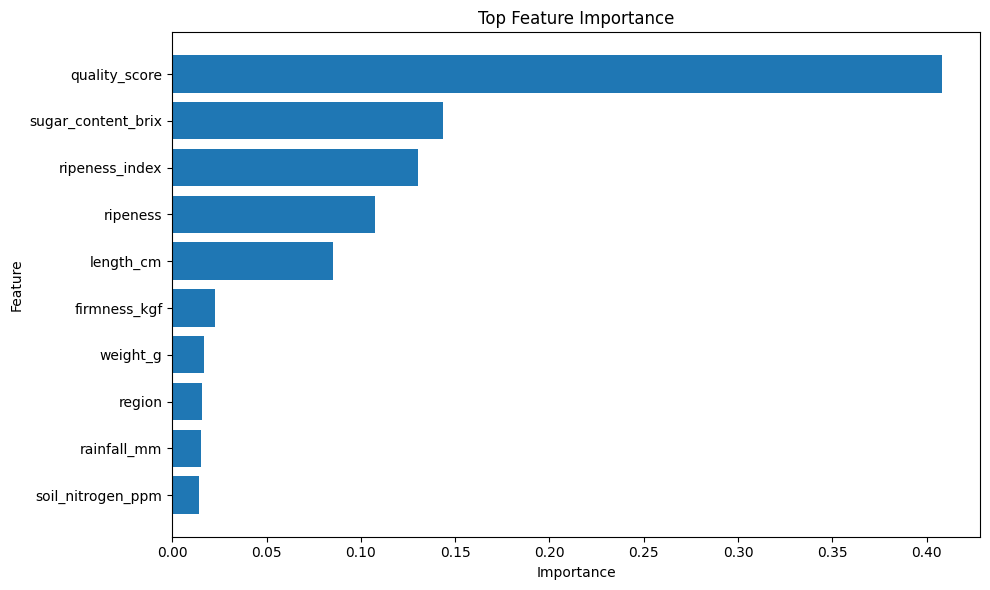

In [16]:
plot_df = top_features.sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importance")
plt.tight_layout()
plt.show()


## 12. Create a practical feature-selection recommendation

We select features whose importance is at least 1% of total model importance. If that would select nothing, the top 5 features are returned instead.

This is a practical baseline, not a universal mathematical cutoff.

In [17]:
selected_features = importance_df.loc[
    importance_df["Importance"] >= 0.01, "Feature"
].tolist()

if not selected_features:
    selected_features = importance_df.head(min(5, len(importance_df)))["Feature"].tolist()

print("Recommended features for the next ML model:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")


Recommended features for the next ML model:
1. quality_score
2. sugar_content_brix
3. ripeness_index
4. ripeness
5. length_cm
6. firmness_kgf
7. weight_g
8. region
9. rainfall_mm
10. soil_nitrogen_ppm
11. altitude_m
12. tree_age_years
13. variety


## 13. Ask Gemini to explain the result

Gemini receives the dataset summary and the calculated feature ranking. It does not replace the ML-based importance calculation.

In [18]:
def build_analysis_prompt(df, target_variable, importance_df, selected_features):
    summary = df.describe(include="all").transpose().fillna("")
    summary_text = summary.to_string()
    ranking_text = importance_df.to_string(index=False)

    return f"""You are a senior machine learning analyst.

The goal is to select useful input features for building a machine-learning model.

Target variable: {target_variable}

Dataset summary:
{summary_text}

Model-based feature importance ranking:
{ranking_text}

Recommended features based on the baseline importance threshold:
{selected_features}

Explain:
1. Which features are most important and why they may help predict the target.
2. Which features appear less important.
3. Any possible leakage or columns that should be treated carefully.
4. A concise recommendation of which features to use for the next ML model.

Do not invent correlations or statistics that are not supported by the supplied information.
"""


prompt = build_analysis_prompt(
    df,
    target_variable,
    importance_df,
    selected_features
)

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response.text)

Here is the feature analysis and selection recommendation based on the provided dataset summary and model importance ranking.

---

### 1. Most Important Features
The top features driving the current baseline model predictions are:
* **`quality_score` (40.79% importance):** Measures quality directly as a continuous metric, making it the strongest statistical predictor for `quality_category`.
* **`sugar_content_brix` (14.38% importance):** A key chemical property reflecting sweetness and chemical maturity.
* **`ripeness_index` (13.03% importance) & `ripeness` / `ripeness_category` (10.75% importance):** Direct indicators of the fruit's ripeness state, which heavily influences quality grading.
* **`length_cm` (8.50% importance):** A physical dimension attribute contributing to sizing and quality categorization.

---

### 2. Less Important Features
Features contributing minimal relative predictive power (< 3% each) include:
* **Physical attributes:** `firmness_kgf` (2.25%), `weight_g` (1.

## 14. Final result

The main output of this app is the ranked `importance_df` table and the `selected_features` list. These can be used as the input-feature shortlist for the next machine-learning model.